In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# Load Final Dataset

output_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/"

X_train = pd.read_csv(output_path + "X_train_final.csv")
X_test = pd.read_csv(output_path + "X_test_final.csv")

y_train = pd.read_csv(
    output_path + "y_train_final.csv"
).squeeze("columns")

y_test = pd.read_csv(
    output_path + "y_test_final.csv"
).squeeze("columns")

print("Datasets Loaded Successfully")

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)



Datasets Loaded Successfully

Training Shape : (12365, 44)
Testing Shape  : (3092, 44)


In [3]:
# Verify Dataset

print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("Features :", X_train.shape[1])

print("\nMissing Values")

print("Training :", X_train.isna().sum().sum())
print("Testing  :", X_test.isna().sum().sum())

print("\nTarget Distribution")

print("\nTraining")

print(round(y_train.value_counts(normalize=True)*100,2))

print("\nTesting")

print(round(y_test.value_counts(normalize=True)*100,2))


FINAL DATASET SUMMARY
Training Samples : 12365
Testing Samples  : 3092
Features : 44

Missing Values
Training : 0
Testing  : 0

Target Distribution

Training
Composite_CVD
0    92.71
1     7.29
Name: proportion, dtype: float64

Testing
Composite_CVD
0    92.72
1     7.28
Name: proportion, dtype: float64


In [4]:
# ==========================================================
# Handle Class Imbalance Using SMOTE
# ==========================================================

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print("="*60)
print("AFTER SMOTE")
print("="*60)

print("Training Shape :", X_train_balanced.shape)

print("\nTarget Distribution")

print(y_train_balanced.value_counts())

AFTER SMOTE
Training Shape : (22928, 44)

Target Distribution
Composite_CVD
0    11464
1    11464
Name: count, dtype: int64


In [5]:
# ==========================================================
# Create Random Forest Model
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [6]:
# ==========================================================
# Train Model
# ==========================================================

rf_model.fit(X_train_balanced, y_train_balanced)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [7]:
# ==========================================================
# Predictions
# ==========================================================

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [8]:
# ==========================================================
# Performance
# ==========================================================

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))
print("MCC      :", matthews_corrcoef(y_test, y_pred_rf))

Accuracy : 0.9016817593790427
Precision: 0.36140350877192984
Recall   : 0.4577777777777778
F1 Score : 0.403921568627451
ROC AUC  : 0.9050792543502693
MCC      : 0.35406639372963017


In [9]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2867
           1       0.36      0.46      0.40       225

    accuracy                           0.90      3092
   macro avg       0.66      0.70      0.68      3092
weighted avg       0.91      0.90      0.91      3092



In [10]:
rf_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

rf_importance = rf_importance.sort_values(

    "Importance",

    ascending=False

)

display(rf_importance.head(20))

,Feature,Importance
2,BPQ020,0.125766
3,BPQ090D,0.107318
5,MCQ160A,0.080304
7,RIDAGEYR,0.066203
18,BPQ080,0.059667
28,LBXPFNA,0.047143
35,URXUCD,0.043744
26,LBXMFOS,0.036634
32,SMQ020,0.032646
40,LBXNFOS,0.030291


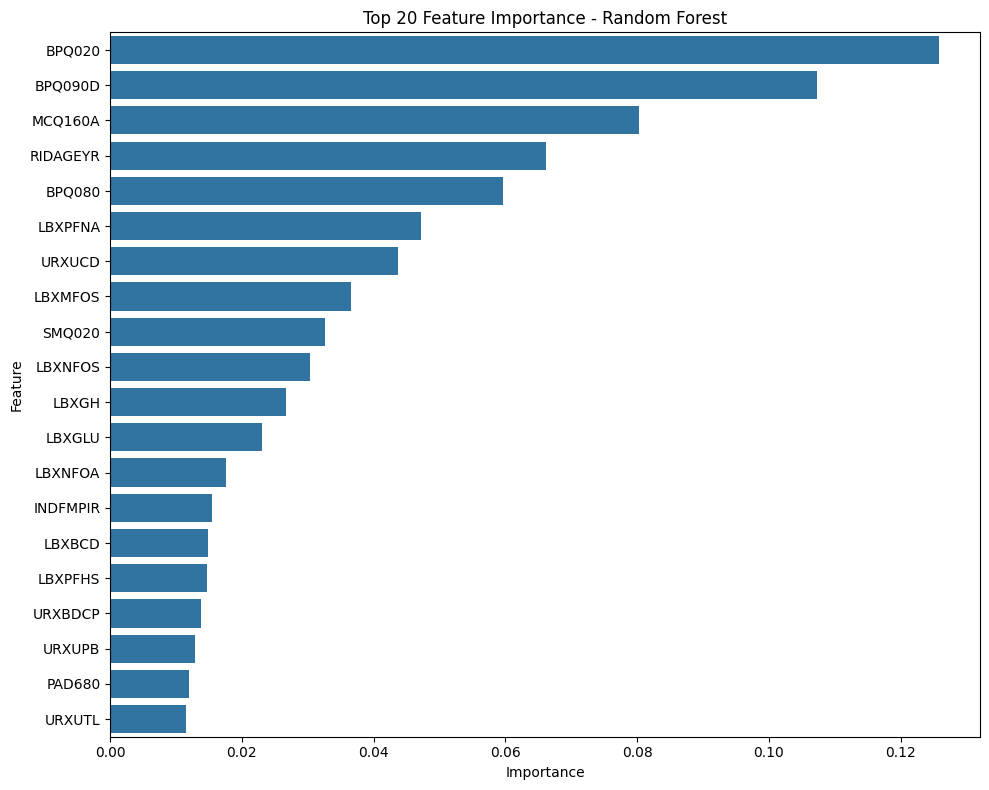

In [11]:
# ==========================================================
# Top 20 Feature Importance
# ==========================================================

rf_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_

})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=rf_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance - Random Forest")

plt.tight_layout()

plt.show()

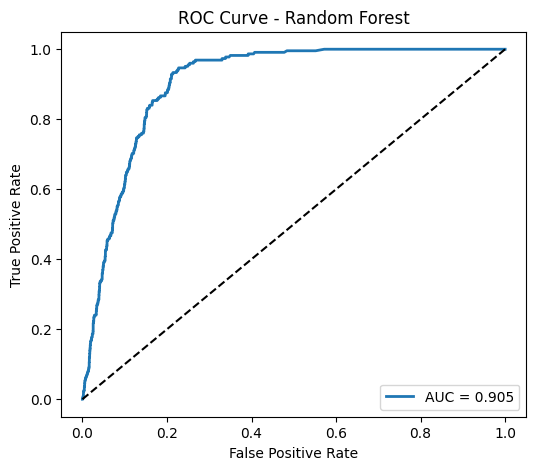

In [12]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

rf_auc = roc_auc_score(y_test, y_prob_rf)


fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2,
         label=f"AUC = {rf_auc:.3f}")

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [13]:
#save Feature Importance

rf_importance.to_csv(

    output_path +

    "Random_Forest_Feature_Importance.csv",

    index=False

)

In [14]:
model_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/"

os.makedirs(model_path, exist_ok=True)

joblib.dump(

    rf_model,

    model_path + "Random_Forest_Model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully
